# Chapter 09 Bayesian Regression: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-09-bayesian-regression-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for "Bayesian Linear Regression and Regularization" (Part 3).

Every function builds one self-contained, standalone Plotly HTML page and writes it to
../_generated/. Figures use closed-form or grid-evaluated posteriors (numpy/scipy only) rather
than running MCMC, so the book can regenerate every figure in seconds without a PyMC
dependency at build time. The chapter's own code listings show the PyMC/ArviZ workflow a
practitioner would reach for; this script exists only to draw the pictures fast.

Run directly to regenerate every figure:
    python chapters/chapter-bayes-regression-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy import stats

RNG = np.random.default_rng(11)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


def simulated_latency_ms(payload_kb: np.ndarray, n_extra: int = 0) -> np.ndarray:
    """Latency as an approximately linear function of payload size, log-normal noise."""
    base = 30 + 9.5 * payload_kb
    noise = RNG.lognormal(mean=0, sigma=0.18, size=payload_kb.shape[0]) * 8
    return base + noise - 8


In [4]:


# ---------------------------------------------------------------------------
# Figure 1: posterior over the payload-size coefficient narrowing as n grows
# ---------------------------------------------------------------------------
def fig_posterior_narrowing() -> go.Figure:
    sample_sizes = [10, 30, 100, 300, 1000]
    prior_mean, prior_var = 0.0, 25.0  # weakly-informative N(0, 5^2) prior on the slope
    noise_var = 2.0**2  # assumed known residual variance for the conjugate update

    payload_full = RNG.uniform(2, 20, size=max(sample_sizes))
    latency_full = simulated_latency_ms(payload_full)

    frames = []
    x_grid = np.linspace(0, 20, 400)
    for n in sample_sizes:
        x = payload_full[:n]
        y = latency_full[:n]
        x_centered = x - x.mean()
        s_xx = float(np.sum(x_centered**2))
        beta_hat = float(np.sum(x_centered * (y - y.mean())) / s_xx) if s_xx > 0 else 0.0

        post_var = 1.0 / (1.0 / prior_var + s_xx / noise_var)
        post_mean = post_var * (prior_mean / prior_var + s_xx * beta_hat / noise_var)
        post_sd = np.sqrt(post_var)

        density = stats.norm.pdf(x_grid, loc=post_mean, scale=post_sd)
        frames.append(
            go.Frame(
                name=f"n={n}",
                data=[go.Scatter(x=x_grid, y=density, mode="lines", fill="tozeroy",
                                  line=dict(color="#4C78A8"))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"posterior mean = {post_mean:.2f} ms/KB<br>posterior sd = {post_sd:.2f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Posterior over the payload-size coefficient as more data arrives",
        xaxis_title="Coefficient value (ms per KB)",
        yaxis_title="Posterior density",
        xaxis_range=[0, 20],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Sample size n: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [5]:


# ---------------------------------------------------------------------------
# Figure 2: 100 repeated-experiment confidence intervals vs. one credible interval
# ---------------------------------------------------------------------------
def fig_ci_vs_credible() -> go.Figure:
    true_beta = 9.5
    n_experiments = 100
    n_per_experiment = 40

    rows_y = []
    rows_lo = []
    rows_hi = []
    contains = []
    for i in range(n_experiments):
        x = RNG.uniform(2, 20, size=n_per_experiment)
        y = simulated_latency_ms(x)
        x_c = x - x.mean()
        s_xx = float(np.sum(x_c**2))
        beta_hat = float(np.sum(x_c * (y - y.mean())) / s_xx)
        resid = y - (y.mean() + beta_hat * x_c)
        sigma_hat = np.sqrt(np.sum(resid**2) / (n_per_experiment - 2))
        se = sigma_hat / np.sqrt(s_xx)
        t_crit = stats.t.ppf(0.975, df=n_per_experiment - 2)
        lo, hi = beta_hat - t_crit * se, beta_hat + t_crit * se
        rows_y.append(i)
        rows_lo.append(lo)
        rows_hi.append(hi)
        contains.append(lo <= true_beta <= hi)

    colors = ["#54A24B" if c else "#E45756" for c in contains]
    coverage = 100 * sum(contains) / n_experiments

    fig = go.Figure()
    for i in range(n_experiments):
        fig.add_trace(go.Scatter(
            x=[rows_lo[i], rows_hi[i]], y=[i, i], mode="lines",
            line=dict(color=colors[i], width=2), showlegend=False, hoverinfo="skip",
        ))
    fig.add_vline(x=true_beta, line=dict(color="#333", width=2, dash="dash"))
    fig.update_layout(
        title=(f"100 independent experiments, each a 95% confidence interval "
               f"({coverage:.0f}% contain the true slope)"),
        xaxis_title="Estimated payload-size coefficient (ms per KB)",
        yaxis_title="Experiment number",
        annotations=[dict(x=true_beta, y=1.04, yref="paper", showarrow=False,
                           text="true slope = 9.5", font=dict(color="#333"))],
        margin=dict(t=90, l=60, r=30, b=50),
    )
    return fig


In [6]:


def fig_credible_interval_single() -> go.Figure:
    x = RNG.uniform(2, 20, size=40)
    y = simulated_latency_ms(x)
    x_c = x - x.mean()
    s_xx = float(np.sum(x_c**2))
    beta_hat = float(np.sum(x_c * (y - y.mean())) / s_xx)

    prior_mean, prior_var = 0.0, 25.0
    noise_var = 2.0**2
    post_var = 1.0 / (1.0 / prior_var + s_xx / noise_var)
    post_mean = post_var * (prior_mean / prior_var + s_xx * beta_hat / noise_var)
    post_sd = np.sqrt(post_var)

    x_grid = np.linspace(post_mean - 5 * post_sd, post_mean + 5 * post_sd, 400)
    density = stats.norm.pdf(x_grid, loc=post_mean, scale=post_sd)
    lo, hi = stats.norm.ppf([0.025, 0.975], loc=post_mean, scale=post_sd)
    mask = (x_grid >= lo) & (x_grid <= hi)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x_grid, y=density, mode="lines", line=dict(color="#4C78A8")))
    fig.add_trace(go.Scatter(x=x_grid[mask], y=density[mask], fill="tozeroy",
                              mode="none", fillcolor="rgba(76,120,168,0.35)"))
    fig.update_layout(
        title=f"One posterior, one 95% credible interval: [{lo:.2f}, {hi:.2f}] ms per KB",
        xaxis_title="Coefficient value (ms per KB)",
        yaxis_title="Posterior density",
        showlegend=False,
        annotations=[dict(
            x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False, align="left",
            text="95% probability the coefficient<br>lies in the shaded region,<br>given this data and this prior",
            font=dict(size=13, color="#333"),
        )],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [7]:


# ---------------------------------------------------------------------------
# Figure 3: Ridge (Gaussian), Lasso (Laplace), and horseshoe prior shapes
# ---------------------------------------------------------------------------
def fig_prior_shapes() -> go.Figure:
    scales = [0.3, 0.6, 1.0, 2.0]
    x_grid = np.linspace(-4, 4, 500)
    frames = []
    for scale in scales:
        gaussian = stats.norm.pdf(x_grid, loc=0, scale=scale)
        laplace = stats.laplace.pdf(x_grid, loc=0, scale=scale / np.sqrt(2))
        # Horseshoe: half-Cauchy local scale x Normal, approximated by numerical marginalization
        local_scales = np.abs(RNG.standard_cauchy(20000)) * scale
        local_scales = np.clip(local_scales, 1e-3, 50)
        horseshoe_samples = RNG.normal(0, local_scales)
        hs_hist, hs_edges = np.histogram(horseshoe_samples, bins=200, range=(-4, 4), density=True)
        hs_x = (hs_edges[:-1] + hs_edges[1:]) / 2

        frames.append(go.Frame(
            name=f"{scale}",
            data=[
                go.Scatter(x=x_grid, y=gaussian, mode="lines", name="Ridge (Gaussian)",
                           line=dict(color="#4C78A8")),
                go.Scatter(x=x_grid, y=laplace, mode="lines", name="Lasso (Laplace)",
                           line=dict(color="#F58518")),
                go.Scatter(x=hs_x, y=hs_hist, mode="lines", name="Horseshoe",
                           line=dict(color="#54A24B")),
            ],
        ))

    fig = go.Figure(data=frames[2].data, frames=frames, layout=go.Layout(
        title="Ridge, Lasso, and horseshoe priors at increasing scale",
        xaxis_title="Coefficient value",
        yaxis_title="Prior density",
        yaxis_range=[0, 2.2],
    ))
    fig.update_layout(
        sliders=[{
            "active": 2,
            "currentvalue": {"prefix": "Prior scale: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
        legend=dict(x=0.02, y=0.98),
    )
    return fig


In [8]:


# ---------------------------------------------------------------------------
# Figure 4: shrinkage profile, Ridge vs. Lasso vs. horseshoe
# ---------------------------------------------------------------------------
def fig_shrinkage_profile() -> go.Figure:
    raw_coef = np.linspace(-6, 6, 400)
    lam = 1.0

    ridge_shrunk = raw_coef / (1 + lam)
    lasso_shrunk = np.sign(raw_coef) * np.maximum(np.abs(raw_coef) - lam, 0)

    # Horseshoe posterior mean approximation (Carvalho, Polson & Scott 2010): shrinkage
    # factor kappa depends on the local shrinkage weight, giving near-unbiased large
    # coefficients and near-total shrinkage for small ones.
    tau2 = 1.0
    kappa = 1 / (1 + tau2)
    horseshoe_shrunk = raw_coef * (1 - kappa * np.exp(-(raw_coef**2) / (2 * tau2 * 3)))

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=raw_coef, y=raw_coef, mode="lines", name="No shrinkage",
                              line=dict(color="#999", dash="dot")))
    fig.add_trace(go.Scatter(x=raw_coef, y=ridge_shrunk, mode="lines", name="Ridge",
                              line=dict(color="#4C78A8")))
    fig.add_trace(go.Scatter(x=raw_coef, y=lasso_shrunk, mode="lines", name="Lasso",
                              line=dict(color="#F58518")))
    fig.add_trace(go.Scatter(x=raw_coef, y=horseshoe_shrunk, mode="lines", name="Horseshoe",
                              line=dict(color="#54A24B")))
    fig.update_layout(
        title="How much each prior shrinks a raw (unregularized) coefficient estimate",
        xaxis_title="Raw coefficient (no shrinkage)",
        yaxis_title="Shrunk coefficient",
        legend=dict(x=0.02, y=0.98),
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [9]:


# ---------------------------------------------------------------------------
# Figure 5: Bayesian logistic regression posterior (grid-evaluated), timeout probability
# ---------------------------------------------------------------------------
def fig_bayesian_logistic() -> go.Figure:
    n = 300
    payload = RNG.uniform(2, 20, size=n)
    logit_p = -4 + 0.35 * payload
    p_timeout = 1 / (1 + np.exp(-logit_p))
    timeout = RNG.binomial(1, p_timeout)

    prior_sds = [10.0, 3.0, 1.0]
    beta_grid = np.linspace(-0.2, 0.9, 600)
    frames = []
    for prior_sd in prior_sds:
        log_prior = stats.norm.logpdf(beta_grid, loc=0, scale=prior_sd)
        log_lik = np.array([
            np.sum(timeout * (b * (payload - payload.mean()))
                   - np.log1p(np.exp(b * (payload - payload.mean()))))
            for b in beta_grid
        ])
        log_post = log_lik + log_prior
        log_post -= log_post.max()
        post = np.exp(log_post)
        dx = beta_grid[1] - beta_grid[0]
        post /= post.sum() * dx
        map_est = beta_grid[np.argmax(post)]

        frames.append(go.Frame(
            name=f"prior sd={prior_sd}",
            data=[go.Scatter(x=beta_grid, y=post, mode="lines", fill="tozeroy",
                              line=dict(color="#B279A2"))],
            layout=go.Layout(annotations=[dict(
                x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False, xanchor="right",
                text=f"posterior mode = {map_est:.3f}",
                font=dict(size=13, color="#333"),
            )]),
        ))

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Grid-evaluated posterior for the timeout-probability logistic coefficient",
        xaxis_title="Coefficient value (log-odds per KB, centered payload)",
        yaxis_title="Posterior density",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Prior std. dev.: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [10]:


# ---------------------------------------------------------------------------
# Figure 6: posterior predictive check, Gaussian-noise model vs. log-normal-noise model
# ---------------------------------------------------------------------------
def fig_posterior_predictive_check() -> go.Figure:
    payload = RNG.uniform(2, 20, size=400)
    observed = simulated_latency_ms(payload)

    beta0, beta1 = 30.0, 9.5
    resid_sd = float(np.std(observed - (beta0 + beta1 * payload)))

    gaussian_sim = (beta0 + beta1 * payload) + RNG.normal(0, resid_sd, size=payload.shape[0])
    lognormal_sim = (beta0 + beta1 * payload - 8) + RNG.lognormal(0, 0.18, size=payload.shape[0]) * 8

    bins = np.linspace(0, 260, 60)
    hist_obs = np.histogram(observed, bins=bins)[0]
    hist_gauss = np.histogram(gaussian_sim, bins=bins)[0]
    hist_ln = np.histogram(lognormal_sim, bins=bins)[0]
    centers = (bins[:-1] + bins[1:]) / 2

    frames = [
        go.Frame(name="Gaussian-noise model", data=[
            go.Bar(x=centers, y=hist_obs, name="Observed", marker_color="#333", opacity=0.55),
            go.Bar(x=centers, y=hist_gauss, name="Posterior predictive draw",
                   marker_color="#E45756", opacity=0.55),
        ]),
        go.Frame(name="Log-normal-noise model", data=[
            go.Bar(x=centers, y=hist_obs, name="Observed", marker_color="#333", opacity=0.55),
            go.Bar(x=centers, y=hist_ln, name="Posterior predictive draw",
                   marker_color="#54A24B", opacity=0.55),
        ]),
    ]

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        barmode="overlay",
        title="Posterior predictive check: does the fitted model's noise assumption fit?",
        xaxis_title="Latency (ms)",
        yaxis_title="Requests",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Noise model: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [11]:


FIGURES = {
    "chapter-bayes-regression-fig-posterior-narrowing": fig_posterior_narrowing,
    "chapter-bayes-regression-fig-ci-repeated-experiments": fig_ci_vs_credible,
    "chapter-bayes-regression-fig-credible-interval-single": fig_credible_interval_single,
    "chapter-bayes-regression-fig-prior-shapes": fig_prior_shapes,
    "chapter-bayes-regression-fig-shrinkage-profile": fig_shrinkage_profile,
    "chapter-bayes-regression-fig-bayesian-logistic": fig_bayesian_logistic,
    "chapter-bayes-regression-fig-posterior-predictive-check": fig_posterior_predictive_check,
}


**`chapter-bayes-regression-fig-posterior-narrowing`**

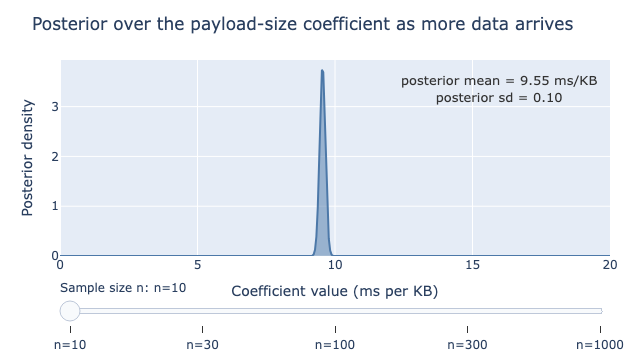

In [12]:
fig = FIGURES["chapter-bayes-regression-fig-posterior-narrowing"]()
fig

**`chapter-bayes-regression-fig-ci-repeated-experiments`**

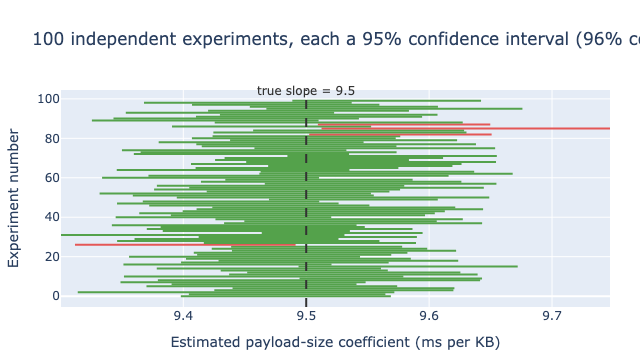

In [13]:
fig = FIGURES["chapter-bayes-regression-fig-ci-repeated-experiments"]()
fig

**`chapter-bayes-regression-fig-credible-interval-single`**

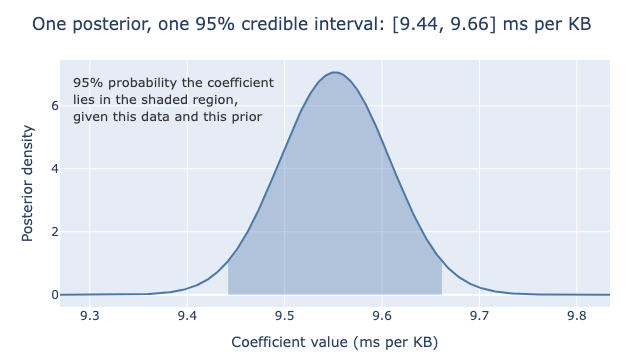

In [14]:
fig = FIGURES["chapter-bayes-regression-fig-credible-interval-single"]()
fig

**`chapter-bayes-regression-fig-prior-shapes`**

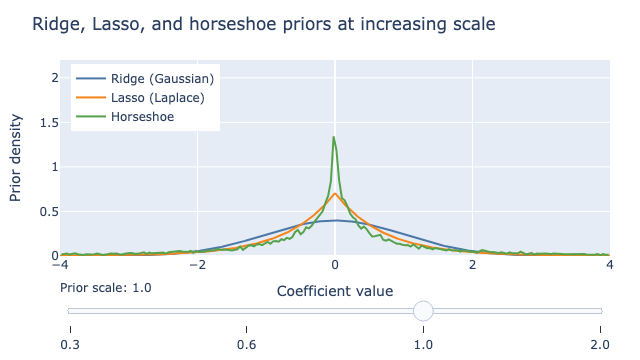

In [15]:
fig = FIGURES["chapter-bayes-regression-fig-prior-shapes"]()
fig

**`chapter-bayes-regression-fig-shrinkage-profile`**

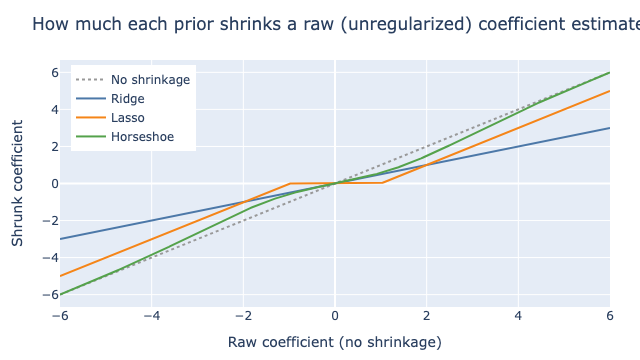

In [16]:
fig = FIGURES["chapter-bayes-regression-fig-shrinkage-profile"]()
fig

**`chapter-bayes-regression-fig-bayesian-logistic`**

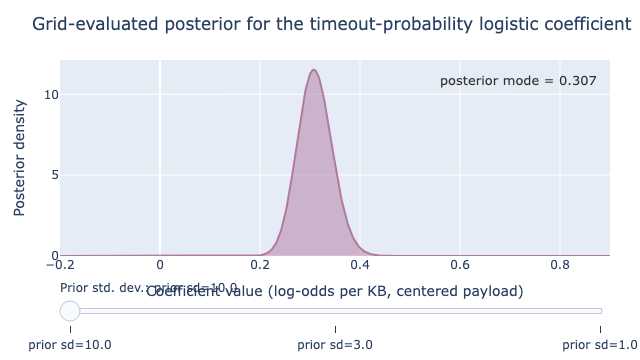

In [17]:
fig = FIGURES["chapter-bayes-regression-fig-bayesian-logistic"]()
fig

**`chapter-bayes-regression-fig-posterior-predictive-check`**

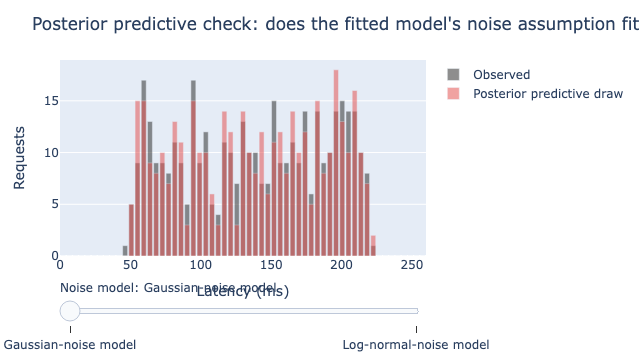

In [18]:
fig = FIGURES["chapter-bayes-regression-fig-posterior-predictive-check"]()
fig